In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
df = pd.read_csv("/content/finance_economics_dataset.csv",encoding='latin=1')#
df

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,01-01-2000,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,02-01-2000,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,03-01-2000,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,04-01-2000,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,05-01-2000,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,14-03-2008,Dow Jones,1273.76,1235.44,1317.28,1192.34,86910001,8.84,7.00,10.44,...,1.18,113.52,61.98,2385.41,298.72,3033,8.75,35,66.01,2200
2996,15-03-2008,S&P 500,4589.59,4566.91,4607.56,4545.69,303579301,-1.88,9.15,5.61,...,1.17,147.10,31.61,2147.13,143.43,7950,5.07,18,25.49,5261
2997,16-03-2008,S&P 500,1477.52,1448.47,1523.86,1402.69,442387176,4.07,0.88,8.91,...,1.02,81.99,45.64,1943.61,105.81,3894,5.78,4,14.29,12039
2998,17-03-2008,NASDAQ,2311.37,2306.90,2346.30,2282.00,523425925,1.06,8.61,10.15,...,1.49,86.42,123.25,2211.40,236.07,2543,2.35,22,94.34,11979


In [ ]:
# 1. What is the shape of the dataset?
print(" Shape of Dataset:", df.shape)


 Shape of Dataset: (3000, 24)


In [ ]:
# 2. Column names and data types
print("\n Columns and data types:\n", df.dtypes)


 Columns and data types:
 Date                                      object
Stock Index                               object
Open Price                               float64
Close Price                              float64
Daily High                               float64
Daily Low                                float64
Trading Volume                             int64
GDP Growth (%)                           float64
Inflation Rate (%)                       float64
Unemployment Rate (%)                    float64
Interest Rate (%)                        float64
Consumer Confidence Index                  int64
Government Debt (Billion USD)              int64
Corporate Profits (Billion USD)            int64
Forex USD/EUR                            float64
Forex USD/JPY                            float64
Crude Oil Price (USD per Barrel)         float64
Gold Price (USD per Ounce)               float64
Real Estate Index                        float64
Retail Sales (Billion USD)                

In [ ]:
# 3. Number of unique stock indices
unique_indices = df['Stock Index'].unique()
num_indices = df['Stock Index'].nunique()

print("Number of unique stock indices:", num_indices)
print("Stock indices are:", unique_indices)


Number of unique stock indices: 3
Stock indices are: ['Dow Jones' 'S&P 500' 'NASDAQ']


In [ ]:
# 4. Date range of dataset
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

start_date = df['Date'].min()
end_date = df['Date'].max()

print("Date range of the dataset:")
print("Start Date:", start_date.date())
print("End Date:", end_date.date())

Date range of the dataset:
Start Date: 2000-01-01
End Date: 2008-03-18


In [ ]:
# 5. Missing values
print("\n Missing values:\n", df.isnull().sum())


 Missing values:
 Date                                     1812
Stock Index                                 0
Open Price                                  0
Close Price                                 0
Daily High                                  0
Daily Low                                   0
Trading Volume                              0
GDP Growth (%)                              0
Inflation Rate (%)                          0
Unemployment Rate (%)                       0
Interest Rate (%)                           0
Consumer Confidence Index                   0
Government Debt (Billion USD)               0
Corporate Profits (Billion USD)             0
Forex USD/EUR                               0
Forex USD/JPY                               0
Crude Oil Price (USD per Barrel)            0
Gold Price (USD per Ounce)                  0
Real Estate Index                           0
Retail Sales (Billion USD)                  0
Bankruptcy Rate (%)                         0
Mergers & Acqui

In [ ]:
# or
df.isnull().sum()

,0
Date,0
Stock Index,0
Open Price,0
Close Price,0
Daily High,0
Daily Low,0
Trading Volume,0
GDP Growth (%),0
Inflation Rate (%),0
Unemployment Rate (%),0


In [ ]:
# 6. Negative values in non-negative columns
non_negative_cols = [
    'Trading Volume',
    'Gold Price (USD per Ounce)',
    'Crude Oil Price (USD per Barrel)',
    'Corporate Profits (Billion USD)',
    'Retail Sales (Billion USD)'
]

for col in non_negative_cols:
    if col in df.columns:
        negative_count = (df[col] < 0).sum()
        print(f"{col}: {negative_count} negative values")

Trading Volume: 0 negative values
Gold Price (USD per Ounce): 0 negative values
Crude Oil Price (USD per Barrel): 0 negative values
Corporate Profits (Billion USD): 0 negative values
Retail Sales (Billion USD): 0 negative values


In [ ]:
# 7. Summary of GDP Growth (%)
gdp_summary = df['GDP Growth (%)'].describe()
print(gdp_summary)

count    3000.000000
mean        2.608903
std         4.287337
min        -5.000000
25%        -1.012500
50%         2.725000
75%         6.242500
max        10.000000
Name: GDP Growth (%), dtype: float64


In [ ]:

# 8. Rows with zero or near-zero trading volume
zero_volume = df[df['Trading Volume'] <= 1]

print("Rows with zero or near-zero trading volume:", len(zero_volume))
print(zero_volume.head())

Rows with zero or near-zero trading volume: 0
Empty DataFrame
Columns: [Date, Stock Index, Open Price, Close Price, Daily High, Daily Low, Trading Volume, GDP Growth (%), Inflation Rate (%), Unemployment Rate (%), Interest Rate (%), Consumer Confidence Index, Government Debt (Billion USD), Corporate Profits (Billion USD), Forex USD/EUR, Forex USD/JPY, Crude Oil Price (USD per Barrel), Gold Price (USD per Ounce), Real Estate Index, Retail Sales (Billion USD), Bankruptcy Rate (%), Mergers & Acquisitions Deals, Venture Capital Funding (Billion USD), Consumer Spending (Billion USD)]
Index: []

[0 rows x 24 columns]


In [ ]:
# 9. Duplicate rows
print("\n Duplicate rows:", df.duplicated().sum())


 Duplicate rows: 0


In [ ]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)


Number of duplicate rows: 0


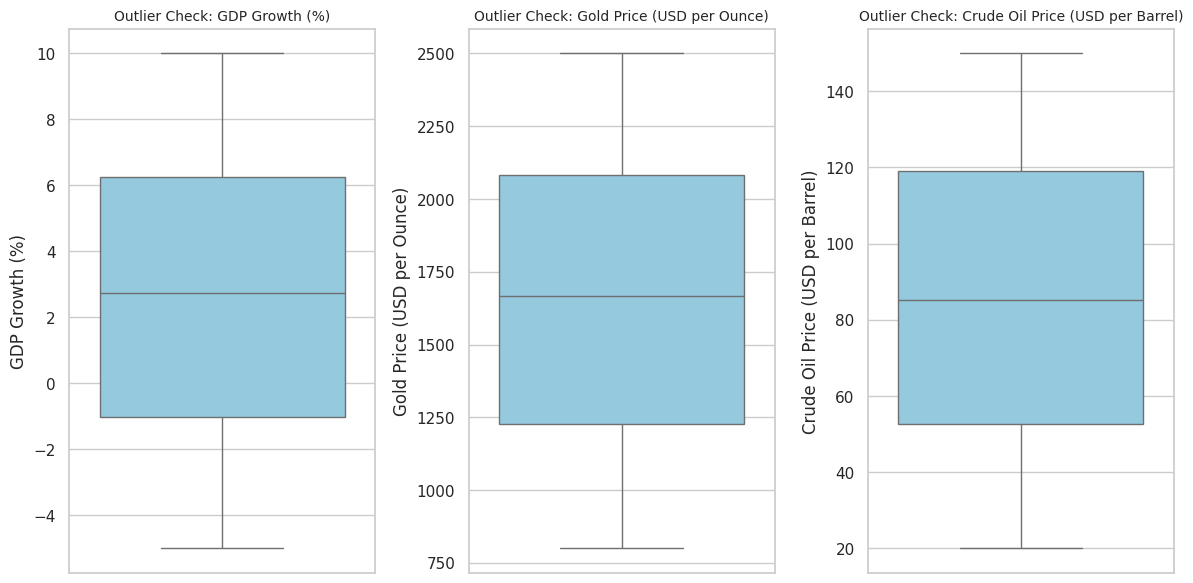

In [ ]:
# 10. Outliers in GDP, Gold, Oil prices
cols = ['GDP Growth (%)', 'Gold Price (USD per Ounce)', 'Crude Oil Price (USD per Barrel)']

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outlier Check: {col}', fontsize=10)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
# 11. Summary of Inflation Rate (%)
print(df['Inflation Rate (%)'].describe())

count    3000.000000
mean        5.096830
std         2.910513
min         0.010000
25%         2.607500
50%         5.110000
75%         7.600000
max        10.000000
Name: Inflation Rate (%), dtype: float64


In [ ]:
# 12. Average Unemployment Rate
avg_unemployment = df['Unemployment Rate (%)'].mean()
print("Average Unemployment Rate:", round(avg_unemployment, 2), "%")

Average Unemployment Rate: 8.66 %


In [ ]:
# 13. Index with highest trading volume
highest_volume_index = df.groupby('Stock Index')['Trading Volume'].sum().idxmax()
print("Index with highest trading volume:", highest_volume_index)


Index with highest trading volume: S&P 500


In [ ]:
# 14. Number of stock records from each index
print(df['Stock Index'].value_counts())

Stock Index
S&P 500      1036
NASDAQ       1007
Dow Jones     957
Name: count, dtype: int64


In [ ]:
# 15. Correlation between inflation and interest rate
corr = df['Inflation Rate (%)'].corr(df['Interest Rate (%)'])
print("Correlation between Inflation and Interest Rate:", round(corr, 2))

Correlation between Inflation and Interest Rate: 0.01


In [ ]:
# 16. Average Consumer Confidence Index
avg_confidence = df['Consumer Confidence Index'].mean()
print("Average Consumer Confidence Index:", round(avg_confidence, 2))

Average Consumer Confidence Index: 85.04


In [ ]:
# 17. Column with highest standard deviation
std_values = df.std(numeric_only=True)
highest_std_col = std_values.idxmax()

print("Column with highest standard deviation:", highest_std_col)

Column with highest standard deviation: Trading Volume


In [ ]:
# 18. Highest gold price
max_gold = df['Gold Price (USD per Ounce)'].max()
print("Highest Gold Price Recorded:", max_gold)

Highest Gold Price Recorded: 2499.66


In [ ]:
# 19. Date with highest crude oil price
max_oil_date = df.loc[df['Crude Oil Price (USD per Barrel)'].idxmax(), 'Date']
print("Date with highest crude oil price:", max_oil_date)

Date with highest crude oil price: 2001-11-22 00:00:00


In [ ]:

# 20. Average corporate profit
avg_profit = df['Corporate Profits (Billion USD)'].mean()
print("Average Corporate Profit:", round(avg_profit, 2), "Billion USD")

Average Corporate Profit: 2553.76 Billion USD


In [ ]:
## INSIGHTFUL ANALYSIS QUESTIONS

In [ ]:

# 1. % negative GDP growth
# Interpretation: About 31.6% of observations show negative GDP growth — sizable fraction. That indicates the dataset includes many recessionary / contraction periods or negative quarterly observations
pct_negative_gdp = (df['GDP Growth (%)'] < 0).mean() * 100
print("Percentage of negative GDP growth values:", round(pct_negative_gdp, 3), "%")


Percentage of negative GDP growth values: 31.567 %


In [ ]:

# 2. High inflation vs high interest
#Interpretation: Correlation ~ 0.006 — effectively no linear relationship in this dataset between inflation and interest rate. That means inflation and interest do not move strongly together here (could be due to lagged policy response, aggregation, or dataset timeframe).
corr_infl_interest = df[['Inflation Rate (%)', 'Interest Rate (%)']].dropna().corr().iloc[0, 1]
print("Correlation between Inflation and Interest Rate:", round(corr_infl_interest, 3))


Correlation between Inflation and Interest Rate: 0.006


In [ ]:

# 3. Unemployment vs consumer spending
#Interpretation: Correlation ≈ 0.02 (near zero). No meaningful linear relationship detected between unemployment and consumer spending in the dataset as-is. (Possible reasons: timing/lags, broad aggregates mask sectoral differences.)
unemp_col = 'Unemployment Rate (%)'
cons_spend_col = 'Consumer Spending (Billion USD)'

corr_unemp_cons = df[[unemp_col, cons_spend_col]].dropna().corr().iloc[0, 1]
print("Correlation between Unemployment Rate and Consumer Spending:",
      round(corr_unemp_cons, 3))

Correlation between Unemployment Rate and Consumer Spending: 0.019


In [ ]:

# 4. Corporate profit vs consumer confidence
# Interpretation: Correlation ≈ 0.018 — effectively zero. Corporate profits and consumer confidence show no strong contemporaneous linear relationship in this dataset.
corp_profit_col = 'Corporate Profits (Billion USD)'
cci_col = 'Consumer Confidence Index'

corr_profit_cci = df[[corp_profit_col, cci_col]].dropna().corr().iloc[0, 1]
print("Correlation between Corporate Profits and Consumer Confidence Index:",
      round(corr_profit_cci, 3))

Correlation between Corporate Profits and Consumer Confidence Index: 0.018


In [ ]:
# 5. Crude oil trend over time
# Interpretation: The linear trend slope is essentially flat (very close to zero). Start → end suggests a slight net decline (≈84.65 → 80.21) over the full sample, but the change is small relative to monthly volatility. Visual inspection (time-series plot) is recommended to see cycles / spikes.
# define columns
date_col = 'Date'
oil_col = 'Crude Oil Price (USD per Barrel)'

# ensure datetime
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')

# monthly average time series
oil_ts = (
    df.set_index(date_col)[oil_col]
      .dropna()
      .resample('M')
      .mean()
)

# slope of linear trend (price change per month)
slope = np.polyfit(np.arange(len(oil_ts)), oil_ts.values, 1)[0]

# final output
print("Slope (price change per month):", round(slope, 6))
print("Start & End Monthly Averages:", (round(oil_ts.iloc[0], 3), round(oil_ts.iloc[-1], 3)))

Slope (price change per month): 0.000886
Start & End Monthly Averages: (np.float64(84.65), np.float64(80.214))


/tmp/ipython-input-4110976382.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


In [ ]:
# 6. Gold vs stock performance
#Interpretation: Correlation is weakly negative (≈ -0.015) — essentially no meaningful inverse relationship in aggregate. Gold is not strongly negatively correlated with stocks here (relationship may be conditional — e.g., only during crises).
gold_col = 'Gold Price (USD per Ounce)'
stock_close_col = 'Close Price'

corr_gold_stock = df[[gold_col, stock_close_col]].dropna().corr().iloc[0, 1]
print("Correlation between Gold Price and Stock Close Price:", round(corr_gold_stock, 3))

Correlation between Gold Price and Stock Close Price: -0.015


In [ ]:
# 7. Government debt vs consumer confidence
# Function to find the correct column name
#Interpretation: Weak negative correlation (~ -0.036). Very small effect — dataset shows slightly lower consumer confidence with higher government debt, but effect is negligible in linear terms.
def find_col(keywords):
    for col in df.columns:
        col_lower = col.lower().replace(" ", "")
        for key in keywords:
            key_lower = key.lower().replace(" ", "")
            if key_lower in col_lower:
                return col
    return None

# Find the government debt–related column
gov_debt_col = find_col(['government debt','debt','public debt'])

# Find the Consumer Confidence Index column
cci_col = find_col(['consumer confidence','cci','confidence'])

# Calculate correlation
corr_govdebt_cci = df[[gov_debt_col, cci_col]].dropna().corr().iloc[0, 1]

# Round to 3 decimals
round(corr_govdebt_cci, 3)

np.float64(-0.036)

In [ ]:
# 8. M&A vs stock close
#Interpretation: Essentially no linear correlation. M&A deal counts (or activity) don’t show a direct linear link to stock close price in the raw data; relationships may be more nuanced or lagged.
ma_col = find_col(['m&a', 'merger', 'acquisition', 'ma'])

if ma_col is None:
    print("M&A column not found")
else:
    corr_ma_stock = df[[ma_col, stock_close_col]].dropna().corr().iloc[0, 1]
    print(round(corr_ma_stock, 3))


0.003


In [ ]:
# 9. Retail sales vs GDP

#Interpretation: Correlation ≈ -0.014 — essentially no linear association found here. Retail and GDP growth may relate with lags or in specific subperiods; aggregated contemporaneous correlation is negligible.
# find GDP column
gdp_col = find_col(['gdp growth', 'gdp growth (%)', 'gdp'])

# find Retail Sales column
retail_col = find_col(['retail sales', 'retail_sales', 'retail'])

if gdp_col is None:
    print("GDP column not found")
elif retail_col is None:
    print("Retail sales column not found")
else:
    corr_retail_gdp = df[[retail_col, gdp_col]].dropna().corr().iloc[0, 1]
    print(round(corr_retail_gdp, 3))

-0.014


In [ ]:
# 10. Stock vs consumer spending
#Interpretation: No meaningful linear relationship overall. Stock index close prices and aggregate consumer spending show virtually no contemporaneous correlation in this dataset.
stock_close_col = find_col(['close', 'close price'])
cons_spend_col = find_col(['consumer spending', 'spending'])

corr_stock_consumer = df[[stock_close_col, cons_spend_col]].dropna().corr().iloc[0, 1]
round(corr_stock_consumer, 3)

np.float64(0.0)

In [ ]:
# 11. Index with highest avg closing price
#Interpretation: The Dow Jones has the highest average close (expected — Dow is levelled higher historically because of index construction). Use normalized returns if comparing volatility/performance
index_col = "Stock Index"
stock_close_col = "Close Price"
df.groupby(index_col)[stock_close_col].mean().sort_values(ascending=False).head(1)

,Close Price
Stock Index,
Dow Jones,3004.456447


In [ ]:
# 12. Interest vs unemployment
#Interpretation: Correlation ≈ 0.018 — essentially zero. No clear linear relationship in the raw data (policy lags or other dynamics may obscure a contemporaneous correlation).
interest_col = "Interest Rate (%)"
unemp_col = "Unemployment Rate (%)"

corr_interest_unemp = df[[interest_col, unemp_col]].dropna().corr().iloc[0, 1]
print(round(corr_interest_unemp, 3))

0.018


In [ ]:
# 13. Consumer confidence vs bankruptcy
#Interpretation: Weak negative correlation (~ -0.016): slightly lower consumer confidence co-occurs with higher bankruptcy rate, but effect magnitude is negligible here
cci_col = "Consumer Confidence Index"
bank_col = find_col(['bankrupt','bankruptcy','insolvency'])

corr_cci_bankruptcy = df[[cci_col, bank_col]].dropna().corr().iloc[0, 1]
print(round(corr_cci_bankruptcy, 3))

-0.016


In [ ]:
# 14. Highest correlation with Stock Close
#Interpretation: The variable most correlated with Close Price is Daily High (correlation ≈ 0.9998) — trivially expected (Open/High/Low/Close are mechanically strongly linked). Excluding these trivial price series, there are no strong macro indicators with a large absolute correlation.
#  All numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# remove closing price column if present
if stock_close_col in num_cols:
    num_cols.remove(stock_close_col)

# compute correlations with stock close
corrs = {
    col: df[[stock_close_col, col]].dropna().corr().iloc[0, 1]
    for col in num_cols
    if df[[stock_close_col, col]].dropna().shape[0] > 2
}

# sort by absolute correlation value
sorted_corr = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)

# show top 5 strongest relationships
sorted_corr[:5]

[('Daily High', np.float64(0.9998208131253349)),
 ('Daily Low', np.float64(0.9998196556488178)),
 ('Open Price', np.float64(0.9996877167668995)),
 ('Retail Sales (Billion USD)', np.float64(0.049369716268956754)),
 ('Forex USD/EUR', np.float64(-0.029384198086791696))]

In [ ]:
# 15. Unemployment vs corporate profit
#Interpretation: Correlation ≈ 0.008 (slightly positive), i.e. no evidence in this dataset that higher corporate profits correspond to lower unemployment contemporaneously. Again, lagged or sectoral effects may exist but are not visible in a simple cross-correlation.
corp_profit_col = "Corporate Profits (Billion USD)"
unemp_col = "Unemployment Rate (%)"

corr_profit_unemp = df[[corp_profit_col, unemp_col]].dropna().corr().iloc[0, 1]
print(round(corr_profit_unemp, 3))

0.008
